Kaggle:
Acute Lymphoblastic Leukemia (ALL) image dataset


In [ ]:
import pandas as pd
import matplotlib as mat
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

pd.options.display.max_colwidth = 100

import random
import os

from numpy.random import seed
seed(42)

random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import glob
import cv2

from tensorflow.random import set_seed
set_seed(42)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mehradaria/leukemia")

100%|██████████| 110M/110M [00:00<00:00, 139MB/s] 

Extracting files...


# EDA

In [ ]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# Root folder
segmentation_root = os.path.join(path, "Segmented")

all_images = []
all_labels = []

classes = ["Benign", "Early", "Pre", "Pro"]

for cls in classes:
    cls_folder = os.path.join(segmentation_root, cls)
    images = glob.glob(os.path.join(cls_folder, "*.*"))
    images = [x for x in images if x.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))]

    all_images.extend(images)
    all_labels.extend([cls] * len(images))

print(f"Total images found: {len(all_images)}")

df = pd.DataFrame({
    "image": all_images,
    "class": all_labels
})

df_train, df_temp = train_test_split(df, test_size=0.3, stratify=df["class"], random_state=42)

df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp["class"], random_state=42)


df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print("Train class distribution:")
print(df_train['class'].value_counts())
print("\nValidation class distribution:")
print(df_val['class'].value_counts())
print("\nTest class distribution:")
print(df_test['class'].value_counts())


Total images found: 3256
Train class distribution:
class
Early     689
Pre       674
Pro       563
Benign    353
Name: count, dtype: int64

Validation class distribution:
class
Early     148
Pre       144
Pro       120
Benign     76
Name: count, dtype: int64

Test class distribution:
class
Early     148
Pre       145
Pro       121
Benign     75
Name: count, dtype: int64


In [ ]:
df_train.describe()

,image,class
count,2279,2279
unique,2279,4
top,/root/.cache/kagglehub/datasets/mehradaria/leukemia/versions/1/Segmented/Early/WBC-Malignant-Ear...,Early
freq,1,689


In [ ]:
df_val.describe()

,image,class
count,488,488
unique,488,4
top,/root/.cache/kagglehub/datasets/mehradaria/leukemia/versions/1/Segmented/Early/WBC-Malignant-Ear...,Early
freq,1,148


In [ ]:
df_test.describe()

,image,class
count,489,489
unique,489,4
top,/root/.cache/kagglehub/datasets/mehradaria/leukemia/versions/1/Segmented/Pre/WBC-Malignant-Pre-4...,Early
freq,1,148


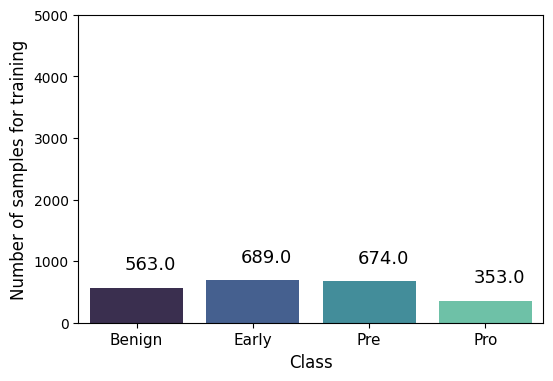

In [ ]:

plt.figure(figsize=(6,4))

ax = sns.countplot(x='class', data=df_train, palette="mako")

plt.xlabel("Class", fontsize= 12)
plt.ylabel("Number of samples for training", fontsize= 12)
plt.ylim(0,5000)
plt.xticks([0,1,2,3], ['Benign', 'Early', 'Pre', 'Pro'], fontsize = 11)

for p in ax.patches:
    ax.annotate((p.get_height()), (p.get_x()+0.30, p.get_height()+300), fontsize = 13)

plt.show()

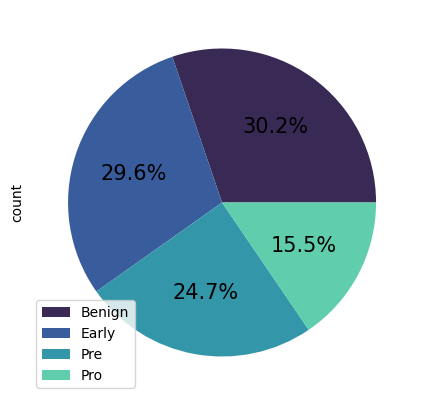

In [ ]:

num_slices = 4
colors = sns.color_palette('mako', num_slices)

plt.figure(figsize=(7,5))

df_train['class'].value_counts().plot(kind='pie',labels = ['','','',''], autopct='%1.1f%%', colors=colors, explode = [0, 0, 0, 0], textprops = {"fontsize":15})

plt.legend(labels=['Benign', 'Early','Pre','Pro'])
plt.show()

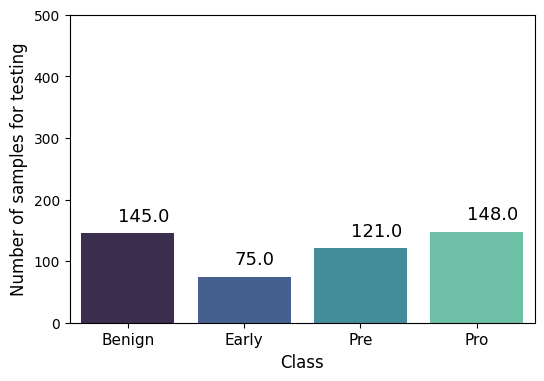

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='class', data=df_test, palette="mako")

plt.xlabel("Class", fontsize= 12)
plt.ylabel("Number of samples for testing", fontsize= 12)
plt.ylim(0,500)
plt.xticks([0,1,2,3], ['Benign', 'Early','Pre','Pro'], fontsize = 11)

for p in ax.patches:
    ax.annotate((p.get_height()), (p.get_x()+0.32, p.get_height()+20), fontsize = 13)

plt.show()

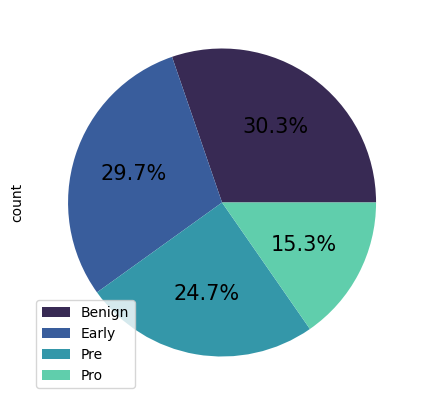

In [ ]:
num_slices = 4
colors = sns.color_palette('mako', num_slices)

plt.figure(figsize=(7,5))

df_test['class'].value_counts().plot(kind='pie',labels = ['','', '',''], autopct='%1.1f%%', colors = colors, explode = [0, 0, 0, 0], textprops = {"fontsize":15})

plt.legend(labels=['Benign', 'Early','Pre','Pro'])
plt.show()

Train Set - Benign


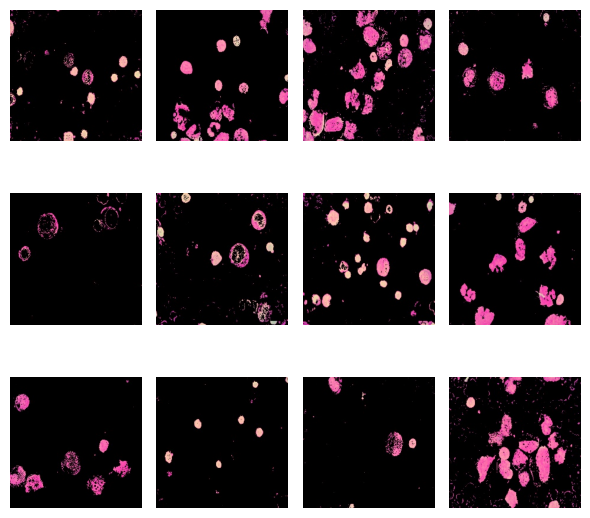

In [ ]:
print('Train Set - Benign')
df_train_benign=df_train[df_train['class']=='Benign'].reset_index(drop=True)
IMG_SIZE = 224

plt.figure(figsize=(6,6))

for i in range(0, 12):
    plt.subplot(3,4,i + 1)
    img_path = df_train_benign.iloc[i]["image"]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

plt.show()

Train Set - Early


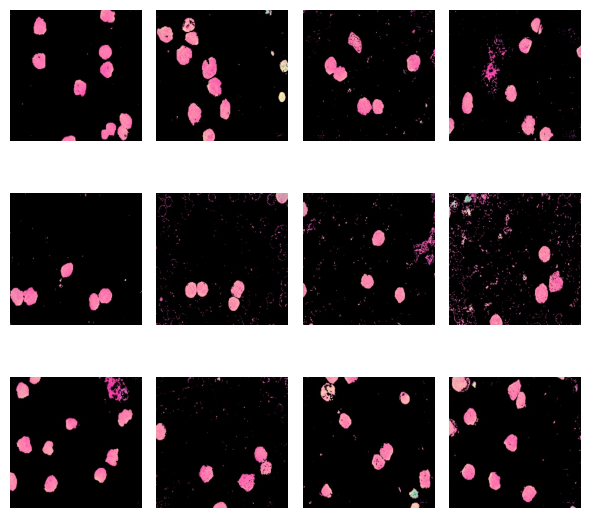

In [ ]:
print('Train Set - Early')
df_train_early=df_train[df_train['class']=='Early'].reset_index(drop=True)
IMG_SIZE=224
plt.figure(figsize=(6,6))

for i in range(0, 12):
    plt.subplot(3,4,i + 1)
    img_path= df_train_early.iloc[i]["image"]
    img=cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

plt.show()

Train Set - Pre


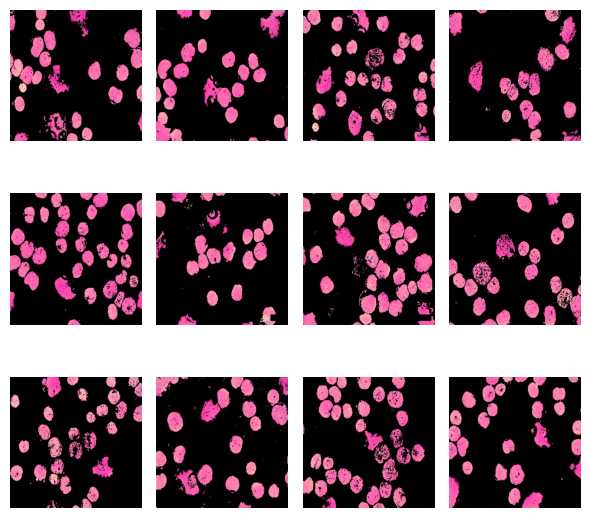

In [ ]:
print('Train Set - Pre')
df_train_pre=df_train[df_train['class']=='Pre'].reset_index(drop=True)

plt.figure(figsize=(6,6))

for i in range(0, 12):
    plt.subplot(3,4,i + 1)
    img_path = df_train_pre.iloc[i]['image']
    img=cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

plt.show()

Train Set - Pro


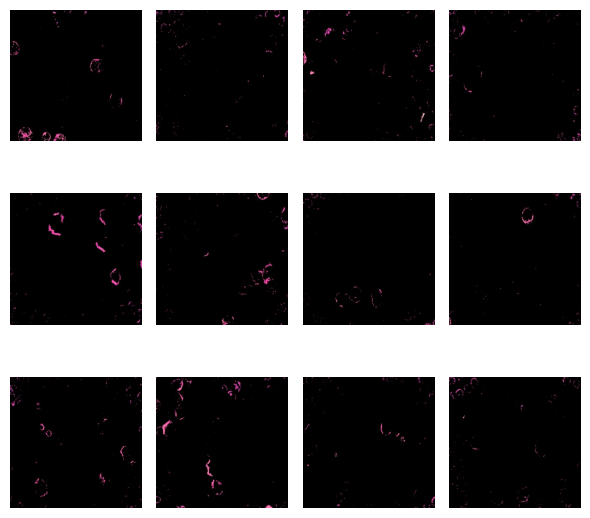

In [ ]:
print('Train Set - Pro')
df_train_pro=df_test[df_test['class']=='Pro'].reset_index(drop=True)

plt.figure(figsize=(6,6))

for i in range(0, 12):
    plt.subplot(3,4,i + 1)
    img_path = df_train_pro.iloc[i]['image']
    img=cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
IMG_SIZE = 224
BATCH = 32
SEED = 42
# train_df, val_df = train_test_split(df_train, test_size = 0.20, random_state = SEED, stratify = df_train['class'])

In [ ]:
# https://vijayabhaskar96.medium.com/tutorial-on-keras-flow-from-dataframe-1fd4493d237c

#applying data augmentation to training sets
train_datagen = ImageDataGenerator(rescale=1/255.,
                                   rotation_range=15,
                                   zoom_range=0.15,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.1,
                                   brightness_range=[0.8, 1.2],
                                   horizontal_flip=True,
                                   fill_mode='nearest')

val_datagen = ImageDataGenerator(rescale=1/255.)

ds_train = train_datagen.flow_from_dataframe(df_train,
                                             x_col = 'image',
                                             y_col = 'class',
                                             target_size = (IMG_SIZE, IMG_SIZE),
                                             class_mode = 'sparse',
                                             shuffle=True,
                                             batch_size = BATCH,
                                             seed = SEED)

ds_val = val_datagen.flow_from_dataframe(df_val,
                                            x_col = 'image',
                                            y_col = 'class',
                                            target_size = (IMG_SIZE, IMG_SIZE),
                                            class_mode = 'sparse',
                                            batch_size = BATCH,
                                            shuffle=False,
                                            seed = SEED)

ds_test = val_datagen.flow_from_dataframe(df_test,
                                            x_col = 'image',
                                            y_col = 'class',
                                            target_size = (IMG_SIZE, IMG_SIZE),
                                            class_mode = 'sparse',
                                            batch_size = 1,
                                            shuffle = False)


print(ds_train.class_indices)
print(ds_val.class_indices)
print(ds_test.class_indices)


Found 2279 validated image filenames belonging to 4 classes.
Found 488 validated image filenames belonging to 4 classes.
Found 489 validated image filenames belonging to 4 classes.
{'Benign': 0, 'Early': 1, 'Pre': 2, 'Pro': 3}
{'Benign': 0, 'Early': 1, 'Pre': 2, 'Pro': 3}
{'Benign': 0, 'Early': 1, 'Pre': 2, 'Pro': 3}


In [ ]:
# check for any labels duplicate
duplicates = df_train[df_train.duplicated('image', keep=False)]
print(duplicates)

Empty DataFrame
Columns: [image, class]
Index: []


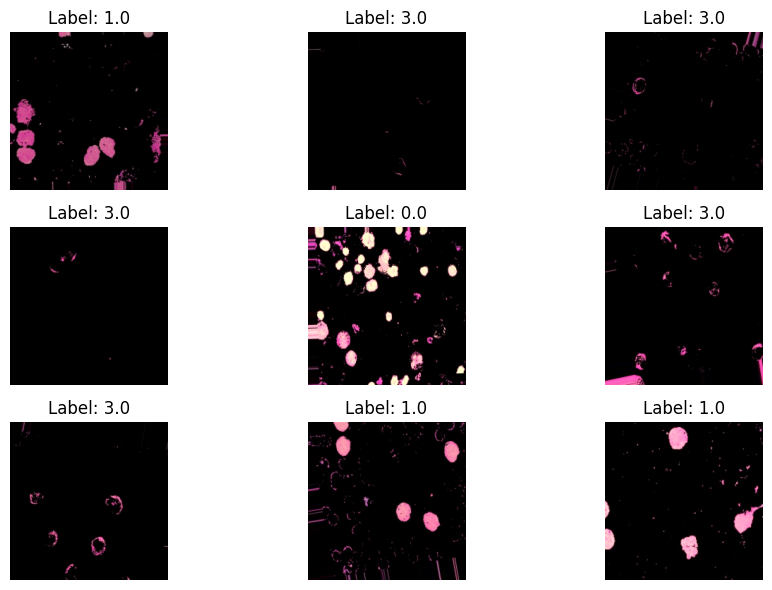

In [ ]:
# plot samples of augmented images

images, labels = next(ds_train)

plt.figure(figsize=(10, 6))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Setting callbakcs

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=1e-7,
    restore_best_weights=True,
)

plateau = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor = 0.2,
    patience = 2,
    min_delt = 1e-7,
    cooldown = 0,
    verbose = 1
)


In [ ]:
from tensorflow.keras.regularizers import l2

def get_model():

    #Input shape = [width, height, color channels]
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Block One
    x = layers.Conv2D(filters=32, kernel_size=3, padding='same',kernel_regularizer=l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    # x = layers.Dropout(0.2)(x)

    # Block Two
    x = layers.Conv2D(filters=64, kernel_size=3, padding='same',kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    # x = layers.Dropout(0.2)(x)

    # Block Three
    x = layers.Conv2D(filters=128, kernel_size=3, padding='same',kernel_regularizer=l2(1e-4))(x)
    x = layers.Conv2D(filters=64, kernel_size=3, padding='same',kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Dropout(0.4)(x)

    # Head
    #x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    #Final Layer (Output)
    output = layers.Dense(4, activation='softmax')(x)
    model = keras.Model(inputs=[inputs], outputs=output)
    return model

In [ ]:
keras.backend.clear_session()

model = get_model()
model.compile(loss='sparse_categorical_crossentropy'
              , optimizer = keras.optimizers.Adam(learning_rate=1e-4), metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,100 (672.27 KB)

 Trainable params: 171,780 (671.02 KB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
import time

start_time = time.time()

history = model.fit(
    ds_train,
    epochs=20,
    validation_data=ds_val,
    callbacks=[early_stopping, plateau]
)


end_time = time.time()

training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 576ms/step - accuracy: 0.5055 - loss: 1.1598 - val_accuracy: 0.2459 - val_loss: 1.4022 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 585ms/step - accuracy: 0.6996 - loss: 0.8666 - val_accuracy: 0.2643 - val_loss: 1.3763 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy: 0.7533 - loss: 0.7164 - val_accuracy: 0.4836 - val_loss: 1.3002 - learning_rate: 1.0000e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 580ms/step - accuracy: 0.8122 - loss: 0.6326 - val_accuracy: 0.5615 - val_loss: 1.1331 - learning_rate: 1.0000e-04
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 565ms/step - accuracy: 0.8335 - loss: 0.5812 - val_accuracy: 0.7090 - val_loss: 0.9645 - learning_rate: 1.0000e-04
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 567ms/step - accuracy: 0.8690 - loss: 0.5178 - val_accuracy: 0.6025 - val_loss: 0.9976 - learning_rate: 1.0000e-04
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 570ms/step - acc

Evaluation - Compare their performance, training time, and complexity.

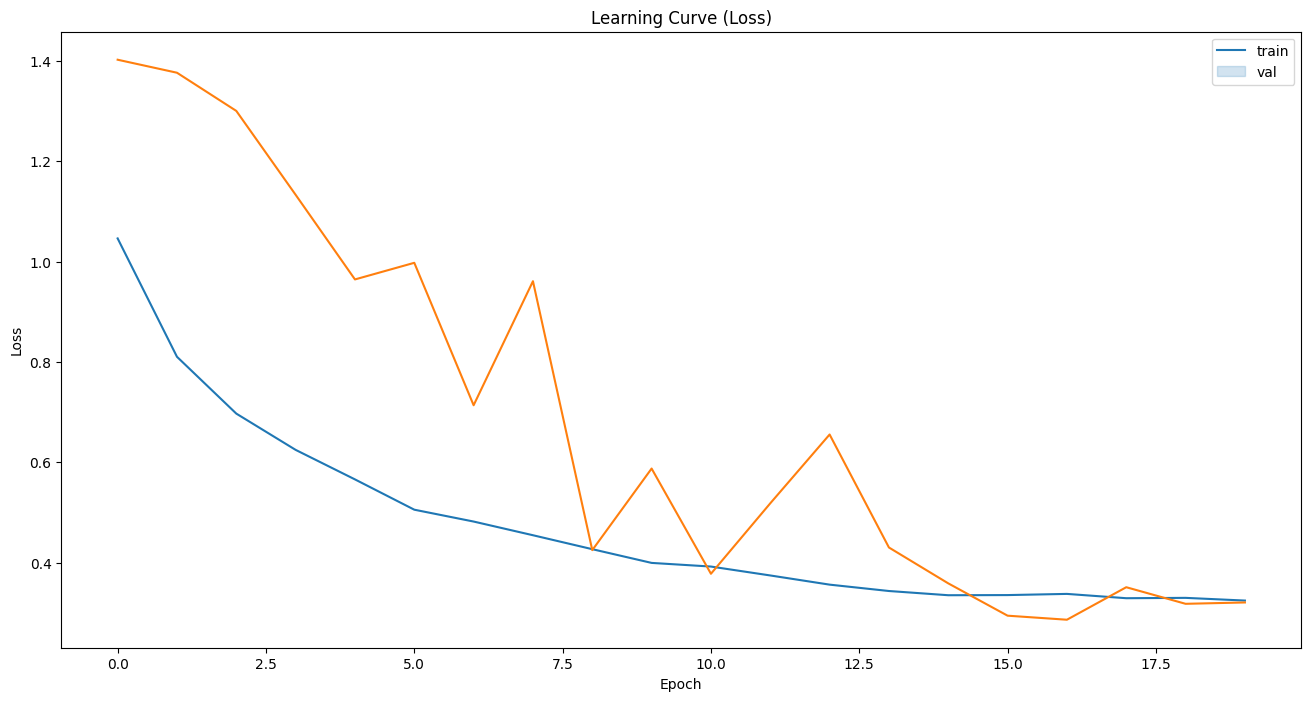

In [ ]:
fig, ax = plt.subplots(figsize=(16,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
ax.set_title('Learning Curve (Loss)')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(['train', 'val'], loc='best')
plt.show()


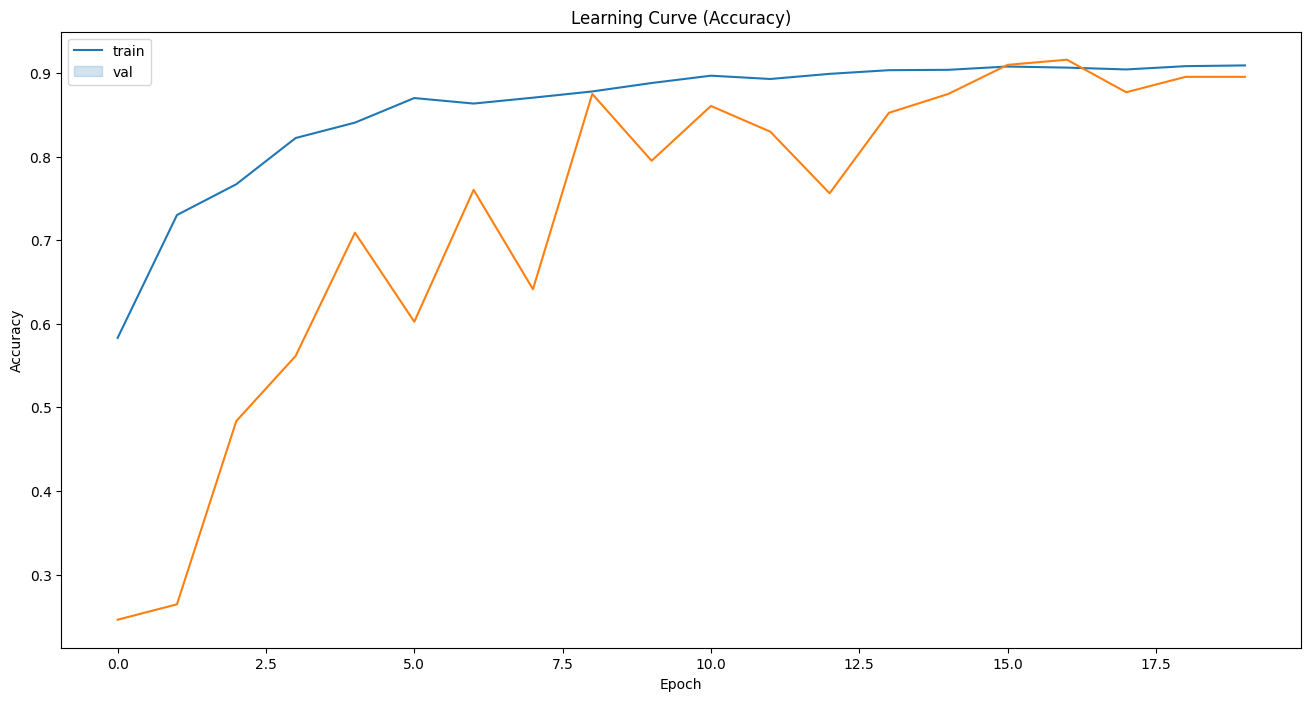

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,8))
sns.lineplot(x = history.epoch, y = history.history['accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_accuracy'])
ax.set_title('Learning Curve (Accuracy)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.legend(['train', 'val'], loc='best')
plt.show()

In [ ]:
score = model.evaluate(ds_val, verbose = 0)
print('Val loss:', score[0])
print('Val accuracy:', score[1])

Val loss: 0.2865408957004547
Val accuracy: 0.9159836173057556


In [ ]:
score = model.evaluate(ds_test,verbose = 0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.30671581625938416
Test accuracy: 0.9161553978919983


In [ ]:
num_label = {'Benign': 0, 'Early': 1, 'Pre': 2, 'Pro': 3}
Y_test = df_test['class'].copy().map(num_label).astype('int')

ds_test.reset()
predictions = model.predict(ds_test, steps=len(ds_test), verbose=0)
pred_labels = np.argmax(predictions, axis=1)

Y_test_labels = Y_test
print("Test Accuracy: ", accuracy_score(Y_test_labels, pred_labels))

Test Accuracy:  0.9161554192229039


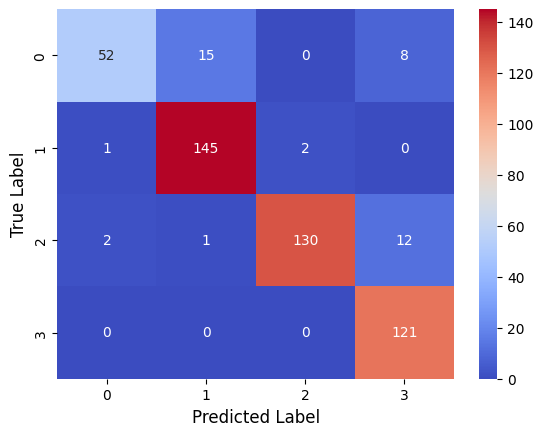

In [ ]:
confusion_matrix = metrics.confusion_matrix(Y_test, pred_labels)
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap='coolwarm')

plt.xlabel("Predicted Label", fontsize= 12)
plt.ylabel("True Label", fontsize= 12)

plt.show()

In [ ]:
print(metrics.classification_report(Y_test, pred_labels, labels = [0, 1,2,3]))

              precision    recall  f1-score   support

           0       0.95      0.69      0.80        75
           1       0.90      0.98      0.94       148
           2       0.98      0.90      0.94       145
           3       0.86      1.00      0.92       121

    accuracy                           0.92       489
   macro avg       0.92      0.89      0.90       489
weighted avg       0.92      0.92      0.91       489



# Upload one image to test

In [ ]:
label_map = {0: 'Benign', 1: 'Early', 2: 'Pre', 3: 'Pro'}
import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)  # change if you used something else

def preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=IMG_SIZE
    )
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = img / 255.0  # remove if you did NOT rescale during training
    img = np.expand_dims(img, axis=0)
    return img
def predict_image(img_path, model):
    img = preprocess_image(img_path)
    preds = model.predict(img)
    pred_class = np.argmax(preds, axis=1)[0]
    confidence = np.max(preds)

    return label_map[pred_class], confidence


In [ ]:
from google.colab import files

uploaded = files.upload()

for img_name in uploaded.keys():
    label, conf = predict_image(img_name, model)
    print(f"Prediction: {label} (Confidence: {conf:.2f})")


Saving test(benign).jpg to test(benign).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Prediction: Benign (Confidence: 0.91)


In [ ]:
preds = model.predict(preprocess_image(img_path))[0]
print(preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[0.03536456 0.02557534 0.02391209 0.915148  ]
